In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("/content/insurance_encoded.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,0,33.770,1,0,2,1725.55230
2,28,0,33.000,3,0,2,4449.46200
3,33,0,22.705,0,0,1,21984.47061
4,32,0,28.880,0,0,1,3866.85520


In [4]:
X = df[['bmi']]      # Independent variable
y = df['charges']    # Dependent variable

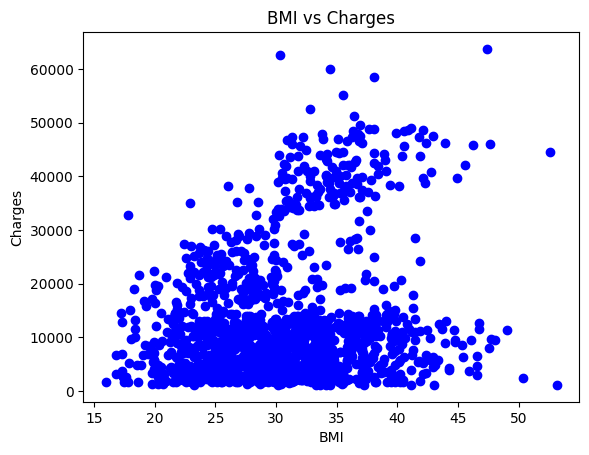

In [5]:
plt.scatter(X, y, color='blue')
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Charges")
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

LinearRegression()

In [8]:
print("Intercept (b):", model_simple.intercept_)
print("Slope (m):", model_simple.coef_[0])

Intercept (b): 1353.0730722046683
Slope (m): 392.43654416987977


In [9]:
y_pred_simple = model_simple.predict(X_test)

In [10]:
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print("Mean Absolute Error (MAE):", mae)
print("R-squared (R²) Score:", r2)

Mean Absolute Error (MAE): 9784.65259627133
R-squared (R²) Score: 0.03970193117941878


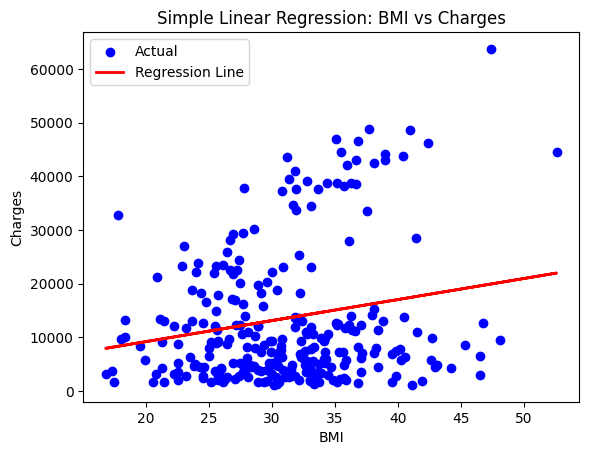

In [11]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred_simple, color='red', linewidth=2, label='Regression Line')
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("Simple Linear Regression: BMI vs Charges")
plt.legend()
plt.show()

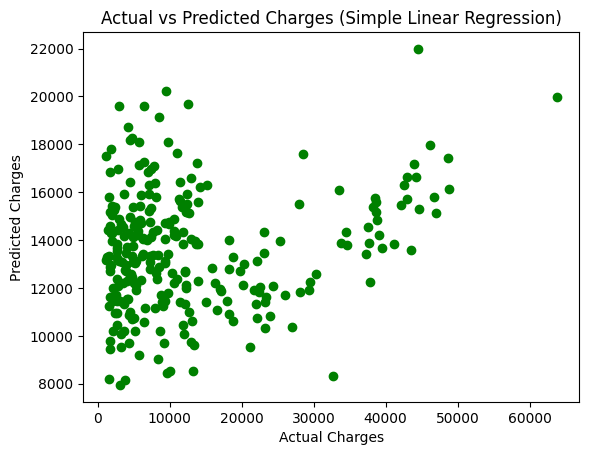

In [12]:
plt.scatter(y_test, y_pred_simple, color='green')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges (Simple Linear Regression)")
plt.show()

In [13]:
import numpy as np

# Example new BMI values
new_bmi = np.array([[25], [30], [35]])

# Predict charges
predicted_charges = model_simple.predict(new_bmi)
for bmi_val, charge in zip(new_bmi.flatten(), predicted_charges):
    print(f"BMI: {bmi_val} → Predicted Charges: {charge:.2f}")

BMI: 25 → Predicted Charges: 11163.99
BMI: 30 → Predicted Charges: 13126.17
BMI: 35 → Predicted Charges: 15088.35


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
**Multiple Linear Regression**
---


In [15]:
X_multi = df.drop('charges', axis=1)

# Dependent variable
y_multi = df['charges']

X_multi.head()

,age,sex,bmi,children,smoker,region
0,19,1,27.900,0,1,3
1,18,0,33.770,1,0,2
2,28,0,33.000,3,0,2
3,33,0,22.705,0,0,1
4,32,0,28.880,0,0,1


In [16]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

In [17]:
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

LinearRegression()

In [18]:
y_pred_multi = model_multi.predict(X_test_m)

In [19]:
mae_multi = mean_absolute_error(y_test_m, y_pred_multi)
r2_multi = r2_score(y_test_m, y_pred_multi)

print("Mean Absolute Error (MAE):", mae_multi)
print("R-squared (R²) Score:", r2_multi)

Mean Absolute Error (MAE): 4186.508898366435
R-squared (R²) Score: 0.7833463107364539


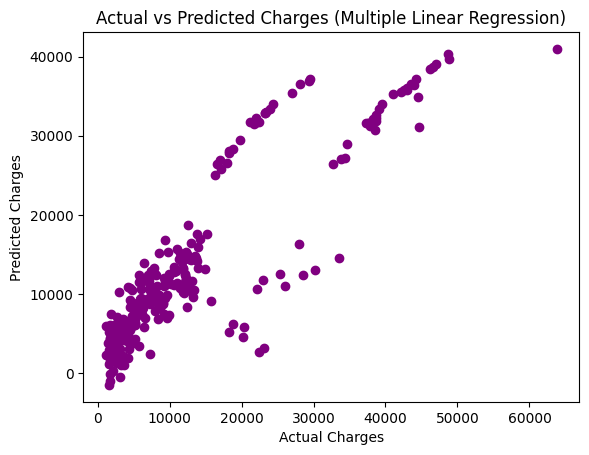

In [20]:
plt.scatter(y_test_m, y_pred_multi, color='purple')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges (Multiple Linear Regression)")
plt.show()

---
**Conclusion**
---

**Simple Linear Regression (BMI → Charges):**

The regression coefficient is positive, indicating that higher BMI leads to higher insurance charges.

The model’s R² score is very low (~0.04) and MAE is high (~9784), which shows that using only BMI is not sufficient to accurately predict insurance charges.

This model provides a basic understanding of the relationship but performs poorly for real-world prediction.

**Multiple Linear Regression (All Features → Charges):**

Including multiple variables such as age, BMI, number of children, sex, smoker status, and region significantly improves the model.

The model’s R² score (~0.78) is much higher, and MAE (~4186) is lower, indicating a much better fit and more accurate predictions.

Smoker status and BMI are among the most influential features affecting charges.

**Overall:**

Simple Linear Regression is useful for understanding individual feature impact.

Multiple Linear Regression is more suitable for real-world prediction since it considers multiple factors and provides a stronger model fit.